# Soccer Ball Detection — YOLOv8s Training

Runs on a Colab GPU runtime.
Upload `data/processed/` to Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install ultralytics

In [10]:
!pip install ultralytics --quiet

## Verify GPU

In [11]:
import torch
print(torch.cuda.is_available())      # must print True
print(torch.cuda.get_device_name(0))  # should print Tesla T4 or similar

True
Tesla T4


## Set paths

Edit `DRIVE_ROOT` if your Drive layout differs.

In [3]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/Junior Year/Summer 2026/Deep Learning/SoccerDetection")
DATA_YAML  = DRIVE_ROOT / "data/processed/data.yaml"
RUNS_DIR   = DRIVE_ROOT / "runs"

# Sanity check
assert DATA_YAML.exists(), f"data.yaml not found at {DATA_YAML}."
print("data.yaml found:", DATA_YAML)

data.yaml found: /content/drive/MyDrive/Junior Year/Summer 2026/Deep Learning/SoccerDetection/data/processed/data.yaml


## Train

Train on the T4 GPU ~3,600 training images.

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")  # downloads pretrained weights automatically
results = model.train(
    data=str(DATA_YAML),
    epochs=75,
    imgsz=640,
    batch=16,
    device="cuda",
    project=str(RUNS_DIR / "train"),
    name="soccer_ball",
    exist_ok=True,
    verbose=True,
)
print("Training complete.")

Ultralytics 8.4.88 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Junior Year/Summer 2026/Deep Learning/SoccerDetection/data/processed/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=soccer_ball, nbs=64, nms=Fals

## Copy best.pt to Drive for download

In [4]:
import shutil

best_src = RUNS_DIR / "train" / "soccer_ball" / "weights" / "best.pt"
best_dst = DRIVE_ROOT / "models" / "best.pt"
best_dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(best_src, best_dst)
print(f"best.pt saved to Drive: {best_dst}")

best.pt saved to Drive: /content/drive/MyDrive/Junior Year/Summer 2026/Deep Learning/SoccerDetection/models/best.pt


## Plot training curves

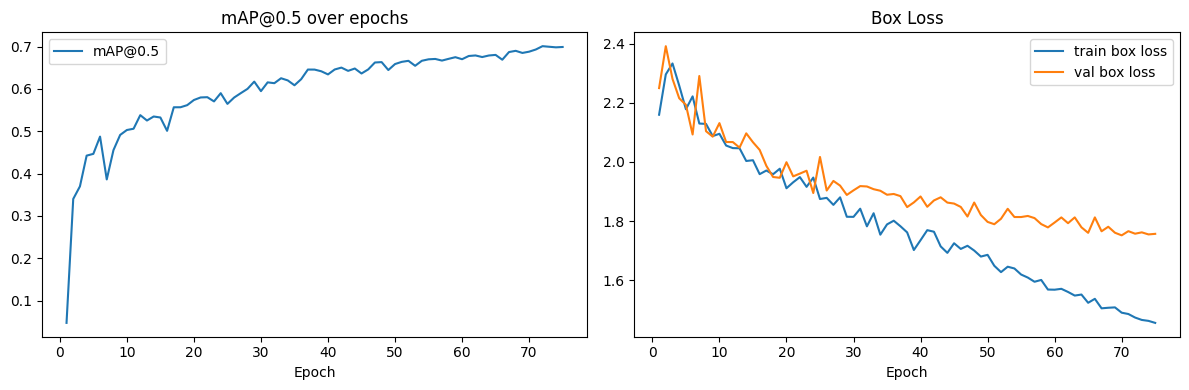

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUNS_DIR / "train" / "soccer_ball" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
axes[0].set_title("mAP@0.5 over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(df["epoch"], df["train/box_loss"], label="train box loss")
axes[1].plot(df["epoch"], df["val/box_loss"], label="val box loss")
axes[1].set_title("Box Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()